# LLM Extraction Evaluation

This notebook evaluates the quality of LLM-extracted FIR documents by comparing them against ground truth data.

## Evaluation Metrics (Data Stays Local - 100% Private)

1. **Semantic Similarity** (using Sentence Transformers)
   - Compares meaning of extracted text vs truth data
   - Range: 0-1 (higher is better)
   - Uses local embeddings (NO data uploaded to cloud)

2. **ROUGE-L Score**
   - Measures longest common subsequence between texts
   - Range: 0-1 (higher is better)
   - Captures how much information is preserved

3. **Content Completeness**
   - Checks if extracted text contains key information from original
   - Measured as: extracted_length / truth_length ratio
   - Helps identify if extraction is too brief or missing content

## Why These Metrics?
-  Semantic Similarity: Does the LLM understand the content correctly?
-  ROUGE-L: How much information is preserved in the extraction?
-  Content Completeness: Is the extraction proportional to original length?

These metrics identify the **BEST LLM** for your FIR extraction task.

In [2]:
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from rouge_score import rouge_scorer

# Initialize semantic similarity model (downloads locally on first use)
print("Initializing Sentence Transformer model...")
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded (runs locally, your data stays private)\n")

# Initialize ROUGE scorer
rouge_scorer_obj = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

# Define paths
LLM_OUTPUTS_DIR = "../data/llm_extracted_outputs"
TRUTH_DATA_FILE = "../data/truth_data_Cr.No.01-2017.txt"
RESULTS_OUTPUT_DIR = "../data/extraction_evaluation_results"

# Create output directory
os.makedirs(RESULTS_OUTPUT_DIR, exist_ok=True)

def load_truth_data(filepath):
    """Load ground truth data from file."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Truth data file not found: {filepath}")
    
    with open(filepath, "r", encoding="utf-8") as f:
        return f.read().strip()

def load_llm_output(filepath):
    """Load LLM extraction output from file."""
    if not os.path.exists(filepath):
        return None
    
    with open(filepath, "r", encoding="utf-8") as f:
        return f.read().strip()

def calculate_semantic_similarity(text1, text2):
    """Calculate semantic similarity using Sentence Transformers (runs locally).
    Returns value between 0 and 1, where 1 is perfect match."""
    try:
        embeddings1 = semantic_model.encode(text1, convert_to_tensor=True)
        embeddings2 = semantic_model.encode(text2, convert_to_tensor=True)
        similarity = util.cos_sim(embeddings1, embeddings2)
        return float(similarity) * 100  # Convert to percentage
    except Exception as e:
        print(f"Error calculating semantic similarity: {e}")
        return 0

def calculate_rouge_l(predicted, reference):
    """Calculate ROUGE-L score (longest common subsequence).
    Returns value between 0 and 1."""
    try:
        scores = rouge_scorer_obj.score(reference, predicted)
        rouge_l_score = scores['rougeL'].fmeasure
        return rouge_l_score * 100  # Convert to percentage
    except Exception as e:
        print(f"Error calculating ROUGE-L: {e}")
        return 0

def calculate_content_completeness(extracted_text, truth_text):
    """Calculate content completeness ratio.
    Measures: extracted_length / truth_length
    Range: 0-100% (100% = same length as original)"""
    if len(truth_text) == 0:
        return 0
    
    extracted_words = len(extracted_text.split())
    truth_words = len(truth_text.split())
    
    # Calculate ratio (capped at 100% to avoid values > 100 for longer outputs)
    ratio = min((extracted_words / truth_words) * 100, 100)
    return ratio

def evaluate_single_output(model_name, llm_output, truth_data):
    """Evaluate a single LLM output against truth data using semantic metrics."""
    results = {
        "model": model_name,
        "text_length_llm": len(llm_output) if llm_output else 0,
        "text_length_truth": len(truth_data),
        "word_count_llm": len(llm_output.split()) if llm_output else 0,
        "word_count_truth": len(truth_data.split()),
    }
    
    if llm_output:
        # 1. Semantic Similarity (runs locally)
        results["semantic_similarity"] = calculate_semantic_similarity(llm_output, truth_data)
        
        # 2. ROUGE-L Score
        results["rouge_l_score"] = calculate_rouge_l(llm_output, truth_data)
        
        # 3. Content Completeness
        results["content_completeness"] = calculate_content_completeness(llm_output, truth_data)
        
    else:
        results["semantic_similarity"] = 0
        results["rouge_l_score"] = 0
        results["content_completeness"] = 0
    
    return results

# Load truth data
print("Loading truth data...")
truth_data = load_truth_data(TRUTH_DATA_FILE)
print(f"Truth data loaded: {len(truth_data)} characters, {len(truth_data.split())} words\n")

# Evaluate all LLM outputs
print("Evaluating LLM outputs...")
print("=" * 80)

# Initialize fresh results list (always reset to avoid duplicates)
all_results = []

# Get all output files
output_files = sorted([f for f in os.listdir(LLM_OUTPUTS_DIR) if f.endswith("_output.txt")])

if not output_files:
    print(f"No output files found in {LLM_OUTPUTS_DIR}")
else:
    for i, output_file in enumerate(output_files, 1):
        model_name = output_file.replace("_output.txt", "")
        filepath = os.path.join(LLM_OUTPUTS_DIR, output_file)
        
        print(f"\n[{i}/{len(output_files)}] Evaluating: {model_name}")
        print("-" * 80)
        
        # Load LLM output
        llm_output = load_llm_output(filepath)
        
        if llm_output is None:
            print(f"  Could not load output file: {filepath}")
            continue
        
        # Evaluate
        results = evaluate_single_output(model_name, llm_output, truth_data)
        all_results.append(results)
        
        # Print results
        print(f"   Semantic Similarity:     {results['semantic_similarity']:.2f}%")
        print(f"   ROUGE-L Score:           {results['rouge_l_score']:.2f}%")
        print(f"   Content Completeness:    {results['content_completeness']:.2f}%")
        print(f"   Word Count (LLM/Truth):  {results['word_count_llm']}/{results['word_count_truth']}")

print("\n" + "=" * 80)

Initializing Sentence Transformer model...
Model loaded (runs locally, your data stays private)

Loading truth data...
Truth data loaded: 9826 characters, 1171 words

Evaluating LLM outputs...

[1/5] Evaluating: DeepSeek-R1-Distill-Llama-8B
--------------------------------------------------------------------------------
Model loaded (runs locally, your data stays private)

Loading truth data...
Truth data loaded: 9826 characters, 1171 words

Evaluating LLM outputs...

[1/5] Evaluating: DeepSeek-R1-Distill-Llama-8B
--------------------------------------------------------------------------------
   Semantic Similarity:     37.73%
   ROUGE-L Score:           35.60%
   Content Completeness:    34.67%
   Word Count (LLM/Truth):  406/1171

[2/5] Evaluating: Llama-3.1-8B-Instruct
--------------------------------------------------------------------------------
   Semantic Similarity:     28.96%
   ROUGE-L Score:           42.04%
   Content Completeness:    42.61%
   Word Count (LLM/Truth):  49

In [3]:
# Create evaluation summary report
if all_results:
    # Convert to DataFrame for better visualization
    results_df = pd.DataFrame(all_results)
    
    print("\nEVALUATION SUMMARY TABLE")
    print("=" * 90)
    
    # Select key metrics
    summary_cols = ["model", "semantic_similarity", "rouge_l_score", "content_completeness"]
    summary_df = results_df[summary_cols].copy()
    summary_df.columns = ["Model", "Semantic Similarity (%)", "ROUGE-L Score (%)", "Content Completeness (%)"]
    
    # Round to 2 decimal places
    for col in summary_df.columns[1:]:
        summary_df[col] = summary_df[col].round(2)
    
    print(summary_df.to_string(index=False))
    print("=" * 90)
    
    # Save detailed results to CSV
    csv_path = os.path.join(RESULTS_OUTPUT_DIR, "llm_extraction_evaluation.csv")
    results_df.to_csv(csv_path, index=False)
    print(f"\n Detailed results saved to: {csv_path}")
    
    # Save results summary to JSON
    json_path = os.path.join(RESULTS_OUTPUT_DIR, "llm_extraction_evaluation.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(all_results, f, indent=2)
    print(f" Results summary saved to: {json_path}")
    
    # Print statistics
    print("\nSTATISTICAL SUMMARY")
    print("=" * 90)
    print(f"Total Models Evaluated:  {len(all_results)}")
    print(f"\nAverage Metrics Across All Models:")
    print(f"  Semantic Similarity:     {results_df['semantic_similarity'].mean():.2f}%")
    print(f"  ROUGE-L Score:           {results_df['rouge_l_score'].mean():.2f}%")
    print(f"  Content Completeness:    {results_df['content_completeness'].mean():.2f}%")
    
    print(f"\nBest Performing Models:")
    best_semantic = results_df.loc[results_df['semantic_similarity'].idxmax()]
    best_rouge = results_df.loc[results_df['rouge_l_score'].idxmax()]
    best_completeness = results_df.loc[results_df['content_completeness'].idxmax()]
    
    print(f"  By Semantic Similarity:  {best_semantic['model']} ({best_semantic['semantic_similarity']:.2f}%)")
    print(f"  By ROUGE-L Score:        {best_rouge['model']} ({best_rouge['rouge_l_score']:.2f}%)")
    print(f"  By Content Completeness: {best_completeness['model']} ({best_completeness['content_completeness']:.2f}%)")
    
    # Calculate overall score (equally weighted)
    results_df['overall_score'] = (
        results_df['semantic_similarity'] * 0.33 +
        results_df['rouge_l_score'] * 0.33 +
        results_df['content_completeness'] * 0.34
    )
    
    best_overall = results_df.loc[results_df['overall_score'].idxmax()]
    print(f"\n BEST OVERALL MODEL:   {best_overall['model']}")
    print(f"   Overall Score: {best_overall['overall_score']:.2f}%")
    print(f"   (Equally weighted: 33% Semantic + 33% ROUGE-L + 34% Completeness)")
    
    print("=" * 90)
else:
    print("✗ No results to display. Check if output files exist in llm_extracted_outputs/")


EVALUATION SUMMARY TABLE
                       Model  Semantic Similarity (%)  ROUGE-L Score (%)  Content Completeness (%)
DeepSeek-R1-Distill-Llama-8B                    37.73              35.60                     34.67
       Llama-3.1-8B-Instruct                    28.96              42.04                     42.61
                  MiniMax-M2                    40.67              58.82                     89.24
         Qwen2.5-7B-Instruct                    25.34              26.02                     79.59
                 gpt-oss-20b                    35.97              60.89                     89.41

 Detailed results saved to: ../data/extraction_evaluation_results/llm_extraction_evaluation.csv
 Results summary saved to: ../data/extraction_evaluation_results/llm_extraction_evaluation.json

STATISTICAL SUMMARY
Total Models Evaluated:  5

Average Metrics Across All Models:
  Semantic Similarity:     33.73%
  ROUGE-L Score:           44.67%
  Content Completeness:    67.11%




 Evaluation charts saved to: ../data/extraction_evaluation_results/llm_extraction_evaluation_charts.png


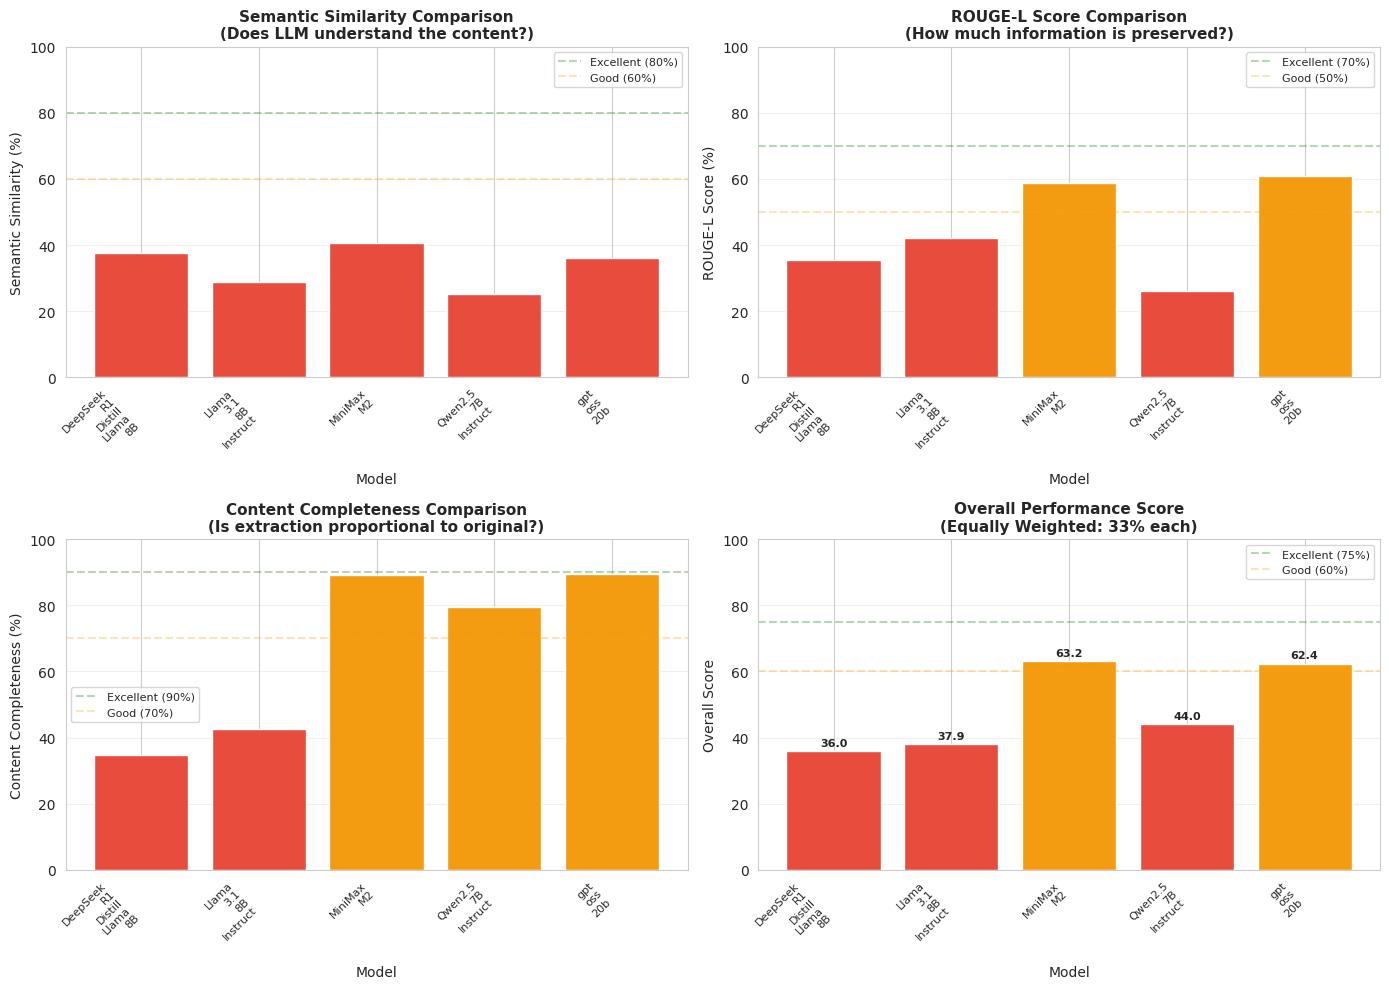

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)

if all_results:
    # Create comparison visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Semantic Similarity Comparison
    ax1 = axes[0, 0]
    models = results_df['model'].tolist()
    semantic = results_df['semantic_similarity'].tolist()
    colors = ['#2ecc71' if s >= 80 else '#f39c12' if s >= 60 else '#e74c3c' for s in semantic]
    ax1.bar(range(len(models)), semantic, color=colors)
    ax1.set_xlabel("Model", fontsize=10)
    ax1.set_ylabel("Semantic Similarity (%)", fontsize=10)
    ax1.set_title("Semantic Similarity Comparison\n(Does LLM understand the content?)", fontsize=11, fontweight='bold')
    ax1.set_xticks(range(len(models)))
    ax1.set_xticklabels([m.replace("-", "\n") for m in models], rotation=45, ha='right', fontsize=8)
    ax1.set_ylim([0, 100])
    ax1.axhline(y=80, color='g', linestyle='--', alpha=0.3, label='Excellent (80%)')
    ax1.axhline(y=60, color='orange', linestyle='--', alpha=0.3, label='Good (60%)')
    ax1.legend(fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. ROUGE-L Score Comparison
    ax2 = axes[0, 1]
    rouge = results_df['rouge_l_score'].tolist()
    colors = ['#2ecc71' if r >= 70 else '#f39c12' if r >= 50 else '#e74c3c' for r in rouge]
    ax2.bar(range(len(models)), rouge, color=colors)
    ax2.set_xlabel("Model", fontsize=10)
    ax2.set_ylabel("ROUGE-L Score (%)", fontsize=10)
    ax2.set_title("ROUGE-L Score Comparison\n(How much information is preserved?)", fontsize=11, fontweight='bold')
    ax2.set_xticks(range(len(models)))
    ax2.set_xticklabels([m.replace("-", "\n") for m in models], rotation=45, ha='right', fontsize=8)
    ax2.set_ylim([0, 100])
    ax2.axhline(y=70, color='g', linestyle='--', alpha=0.3, label='Excellent (70%)')
    ax2.axhline(y=50, color='orange', linestyle='--', alpha=0.3, label='Good (50%)')
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Content Completeness Comparison
    ax3 = axes[1, 0]
    completeness = results_df['content_completeness'].tolist()
    colors = ['#2ecc71' if c >= 90 else '#f39c12' if c >= 70 else '#e74c3c' for c in completeness]
    ax3.bar(range(len(models)), completeness, color=colors)
    ax3.set_xlabel("Model", fontsize=10)
    ax3.set_ylabel("Content Completeness (%)", fontsize=10)
    ax3.set_title("Content Completeness Comparison\n(Is extraction proportional to original?)", fontsize=11, fontweight='bold')
    ax3.set_xticks(range(len(models)))
    ax3.set_xticklabels([m.replace("-", "\n") for m in models], rotation=45, ha='right', fontsize=8)
    ax3.set_ylim([0, 100])
    ax3.axhline(y=90, color='g', linestyle='--', alpha=0.3, label='Excellent (90%)')
    ax3.axhline(y=70, color='orange', linestyle='--', alpha=0.3, label='Good (70%)')
    ax3.legend(fontsize=8)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Overall Score (weighted average)
    ax4 = axes[1, 1]
    overall_scores = results_df['overall_score'].tolist()
    colors_score = ['#2ecc71' if s >= 75 else '#f39c12' if s >= 60 else '#e74c3c' for s in overall_scores]
    bars = ax4.bar(range(len(models)), overall_scores, color=colors_score)
    ax4.set_xlabel("Model", fontsize=10)
    ax4.set_ylabel("Overall Score", fontsize=10)
    ax4.set_title("Overall Performance Score\n(Equally Weighted: 33% each)", fontsize=11, fontweight='bold')
    ax4.set_xticks(range(len(models)))
    ax4.set_xticklabels([m.replace("-", "\n") for m in models], rotation=45, ha='right', fontsize=8)
    ax4.set_ylim([0, 100])
    ax4.axhline(y=75, color='g', linestyle='--', alpha=0.3, label='Excellent (75%)')
    ax4.axhline(y=60, color='orange', linestyle='--', alpha=0.3, label='Good (60%)')
    
    # Add score labels on bars
    for i, (bar, score) in enumerate(zip(bars, overall_scores)):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{score:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax4.legend(fontsize=8)
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_path = os.path.join(RESULTS_OUTPUT_DIR, "llm_extraction_evaluation_charts.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n Evaluation charts saved to: {fig_path}")
    
    plt.show()